In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from Pruning import *
from scipy.linalg import solve, qr
import numpy as np
from Plot import *
import random

# Transform to tensor
dataset_transform = transforms.Compose([
    transforms.ToTensor(),                 
    #transforms.Normalize((0.1307,), (0.3081,))  # Normalization 
])

train_dataset = datasets.MNIST(
    root = "./data",      
    train = True,         
    download = True,      
    transform = dataset_transform
)

test_dataset = datasets.MNIST(
    root = "./data",
    train = False,        
    download = True,
    transform = dataset_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False
)

<img src="nn4MNIST.png" alt="nn" width="600">

In [2]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps" if torch.mps.is_available() else "cpu")
#device = torch.device("cpu")

class Model2(nn.Module):
    def __init__(self):
        super(Model2, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 32, 5),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 5),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.model(x)
        return x
    

model2 = Model2().to(device)

# loss functiom & optimizer
loss_fun = nn.CrossEntropyLoss()
optimizer = optim.SGD(model2.parameters(), lr=0.1, momentum=0.9)

In [3]:
epoch = 5

for i in range(epoch):
    print("-------Epoch {}-------".format(i+1))
    # train
    for imgs, targets in train_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        outputs = model2(imgs)
        loss = loss_fun(outputs, targets)

        # optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # test
    total_test_loss = 0
    total_accuracy = 0
    wrong_indices = []
    base_idx = 0
    with torch.no_grad():
        for imgs, targets in test_loader:
            batch_size = targets.size(0)
            imgs = imgs.to(device)
            targets = targets.to(device)
            outputs = model2(imgs)

            loss0 = loss_fun(outputs, targets)
            total_test_loss = total_test_loss + loss0.item()

            accuracy = (outputs.argmax(1) == targets).sum().item()
            total_accuracy = total_accuracy + accuracy

            # Record indices of misclassified samples
            if i == epoch - 1:  # Only record for the last epoch
                wrong_in_batch = torch.where(outputs.argmax(1) != targets)[0]
                wrong_indices.extend((base_idx + wrong_in_batch).tolist())
                base_idx += batch_size


    print("Total loss in test set: {}".format(total_test_loss))
    print("Total accuracy in test set: {}".format(total_accuracy / len(test_dataset)))

print("Number of samples misclassified by the original model:", len(wrong_indices))

-------Epoch 1-------
Total loss in test set: 0.6144847571849823
Total accuracy in test set: 0.9807
-------Epoch 2-------
Total loss in test set: 0.5446161162108183
Total accuracy in test set: 0.9823
-------Epoch 3-------
Total loss in test set: 0.6568372864276171
Total accuracy in test set: 0.9808
-------Epoch 4-------
Total loss in test set: 0.6082585975527763
Total accuracy in test set: 0.9811
-------Epoch 5-------
Total loss in test set: 0.41500394931063056
Total accuracy in test set: 0.9887
Number of samples misclassified by the original model: 113


In [4]:
batch_list = list(train_loader)
X, _ = random.choice(batch_list)
X = X.to(device)
ratios = np.linspace(0.1, 0.9, 9)
base_acc = total_accuracy / len(test_dataset)
print(X.shape)

torch.Size([64, 1, 28, 28])


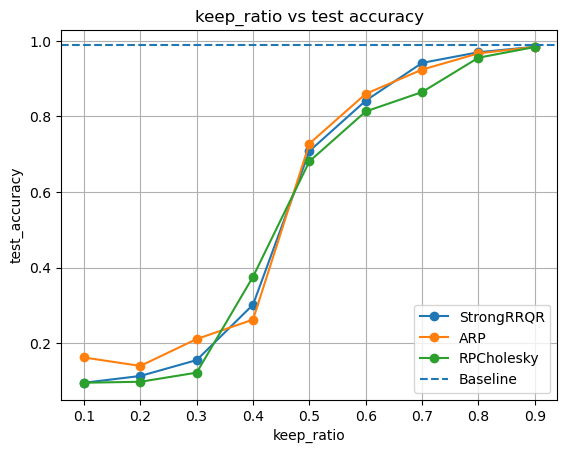

In [10]:
methods = ["StrongRRQR", "ARP", "RPCholesky"]
all_accs = []
for method in methods:
    accs = []
    for r in ratios:
        params_new = prune_model(model2, X, r, method=method)
        pruned_model = load_pruned_model(model2, params_new)
        acc, _ = evaluate_pruned_model(pruned_model, test_loader)
        accs.append(acc)
    all_accs.append(accs)

plot_pruning_curve(base_acc, ratios, all_accs, methods,
                   title="keep_ratio vs test accuracy")

In [11]:
params_new = prune_model(model2, X, 0.7, method="StrongRRQR")
pruned_model = load_pruned_model(model2, params_new)
acc, wrong_samples_pruned = evaluate_pruned_model(pruned_model, test_loader)
print(acc, len(wrong_samples_pruned))

0.9413 587
